<a href="https://colab.research.google.com/github/nastyakurylets/DentalAIProject/blob/main/YOLA_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import yaml
import pandas as pd
import cv2
from pathlib import Path
from tqdm.auto import tqdm
import kagglehub



In [ ]:
# Dataset 1 (Radiography)
path_ds1 = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
base_ds1 = Path(path_ds1) / "dental_radiography"

#  Dataset 2 (OPG)
path_ds2 = kagglehub.dataset_download("imtkaggleteam/dental-opg-xray-dataset")
base_ds2 = Path(path_ds2) / "Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset"

print(f"DS1 Path: {base_ds1}")
print(f"DS2 Path: {base_ds2}")

Using Colab cache for faster access to the 'dental-radiography' dataset.
Using Colab cache for faster access to the 'dental-opg-xray-dataset' dataset.
DS1 Path: /kaggle/input/dental-radiography/dental_radiography
DS2 Path: /kaggle/input/dental-opg-xray-dataset/Dental OPG XRAY Dataset/Dental OPG (Object Detection)/Augmented Dataset


In [ ]:

OUTPUT_DIR = Path("/content/dental_yolo_dataset")

TARGET_CLASSES = ['Caries', 'Impacted', 'Fracture']


DS1_MAP = {
    'Cavity': 0,          # -> Caries
    'Impacted Tooth': 1,  # -> Impacted
    'Fillings': None,     # Ignore
    'Implant': None,      # Ignore
    '__background__': None
}



DS2_MAP = {
    0: None, # Healthy -> Skip
    1: 0,    # Caries -> Caries
    2: 1,    # Impacted -> Impacted
    3: 2,    # Broken -> Fracture
    4: 2,    # Infection -> Fracture (об'єднання патологій)
    5: 2     # Fractured -> Fracture
}

In [ ]:
def create_yolo_dataset(output_path):
    output_path = Path(output_path)

    if output_path.exists():
        shutil.rmtree(output_path)

    for split in ['train', 'valid']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)


    # --- DS1 (Radiography) ---
    for split in ['train', 'valid']:
        csv_file = base_ds1 / split / '_annotations.csv'
        if not csv_file.exists(): continue

        df = pd.read_csv(csv_file)

        for filename, group in tqdm(df.groupby('filename'), desc=f"DS1 {split}"):
            src_img_path = base_ds1 / split / filename
            if not src_img_path.exists(): continue

            img = cv2.imread(str(src_img_path))
            if img is None: continue
            h, w = img.shape[:2]

            yolo_labels = []
            for _, row in group.iterrows():
                if row['class'] not in DS1_MAP or DS1_MAP[row['class']] is None:
                    continue

                cls_id = DS1_MAP[row['class']]

                # XYXY -> XYWH Normalized
                dw, dh = 1. / w, 1. / h
                x_center = (row['xmin'] + row['xmax']) / 2.0 * dw
                y_center = (row['ymin'] + row['ymax']) / 2.0 * dh
                width = (row['xmax'] - row['xmin']) * dw
                height = (row['ymax'] - row['ymin']) * dh

                x_center, y_center = max(0, min(1, x_center)), max(0, min(1, y_center))
                width, height = max(0, min(1, width)), max(0, min(1, height))

                yolo_labels.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

            if yolo_labels:
                new_filename = f"ds1_{filename}"
                shutil.copy(src_img_path, output_path / split / 'images' / new_filename)
                txt_path = output_path / split / 'labels' / Path(new_filename).with_suffix('.txt')
                with open(txt_path, 'w') as f:
                    f.write('\n'.join(yolo_labels))

    # --- DS2 (OPG) ---
    ds2_split_map = {'train': 'train', 'valid': 'valid', 'test': 'valid'}

    for src_split, dst_split in ds2_split_map.items():
        img_dir = base_ds2 / src_split / 'images'
        lbl_dir = base_ds2 / src_split / 'labels'

        if not img_dir.exists(): continue

        for img_file in tqdm(list(img_dir.glob('*.*')), desc=f"DS2 {src_split}"):
            txt_file = lbl_dir / f"{img_file.stem}.txt"
            if not txt_file.exists(): continue

            with open(txt_file, 'r') as f:
                lines = f.readlines()

            new_lines = []
            for line in lines:
                parts = line.strip().split()
                try:
                    orig_id = int(parts[0])
                except ValueError: continue

                if orig_id in DS2_MAP and DS2_MAP[orig_id] is not None:
                    new_id = DS2_MAP[orig_id]
                    new_lines.append(f"{new_id} {' '.join(parts[1:])}")

            if new_lines:
                new_filename = f"ds2_{img_file.name}"
                shutil.copy(img_file, output_path / dst_split / 'images' / new_filename)
                new_txt_path = output_path / dst_split / 'labels' / Path(new_filename).with_suffix('.txt')
                with open(new_txt_path, 'w') as f:
                    f.write('\n'.join(new_lines))

    # --- YAML Config ---
    yaml_content = {
        'path': str(output_path.absolute()),
        'train': 'train/images',
        'val': 'valid/images',
        'nc': len(TARGET_CLASSES),
        'names': TARGET_CLASSES
    }

    yaml_path = output_path / 'dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)

    return yaml_path

# --- ЗАПУСК ГЕНЕРАЦІЇ ---
yaml_file = create_yolo_dataset(OUTPUT_DIR)
print(f"++++++++++++++")

DS2 train:   0%|          | 0/558 [00:00<?, ?it/s]

DS2 valid:   0%|          | 0/23 [00:00<?, ?it/s]

DS2 test:   0%|          | 0/23 [00:00<?, ?it/s]

++++++++++++++


# **Модель**

Імпорт бібліотек та Конфігурація

In [ ]:
import os
import shutil
import yaml
import pandas as pd
import cv2
from pathlib import Path
from tqdm.auto import tqdm

INPUT_DIR = Path("/content/dataset_standard") # Джерело (CSV)
OUTPUT_DIR = Path("/content/dataset_yolo")    # Ціль (TXT для YOLO)

# Конфігурація класів
CLASSES = ['Caries', 'Impacted', 'Fracture'] # Background у YOLO не вказується
CLASS_MAP = {name: i for i, name in enumerate(CLASSES)}

Клас Dataset та Утиліти

In [ ]:
def convert_to_yolo_format(input_path, output_path):
    output_path = Path(output_path)

    if output_path.exists():
        shutil.rmtree(output_path)

    # Створення структури папок
    for split in ['train', 'valid']:
        (output_path / split / 'images').mkdir(parents=True, exist_ok=True)
        (output_path / split / 'labels').mkdir(parents=True, exist_ok=True)

    print(f"Generating YOLO dataset in: {output_path}")

    for split in ['train', 'valid']:
        csv_file = input_path / split / '_annotations.csv'
        if not csv_file.exists():
            print(f"Skipping {split}: CSV not found.")
            continue

        df = pd.read_csv(csv_file)

        # Групування за файлами
        for filename, group in tqdm(df.groupby('filename'), desc=f"Processing {split}"):
            src_img = input_path / split / filename
            if not src_img.exists(): continue

            # 1. Копіювання зображення
            dst_img = output_path / split / 'images' / filename
            shutil.copy(src_img, dst_img)

            # 2. Створення лейблів
            img_h, img_w = group.iloc[0]['height'], group.iloc[0]['width']
            yolo_lines = []

            for _, row in group.iterrows():
                cls_name = row['class']
                if cls_name not in CLASS_MAP: continue

                cls_id = CLASS_MAP[cls_name]

                # Нормалізація XYXY -> XYWH (0.0 - 1.0)
                dw = 1.0 / img_w
                dh = 1.0 / img_h

                x_center = (row['xmin'] + row['xmax']) / 2.0 * dw
                y_center = (row['ymin'] + row['ymax']) / 2.0 * dh
                width = (row['xmax'] - row['xmin']) * dw
                height = (row['ymax'] - row['ymin']) * dh

                yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

            # Запис TXT файлу
            txt_filename = Path(filename).with_suffix('.txt')
            with open(output_path / split / 'labels' / txt_filename, 'w') as f:
                f.write('\n'.join(yolo_lines))

    # Створення dataset.yaml
    yaml_content = {
        'path': str(output_path.absolute()),
        'train': 'train/images',
        'val': 'valid/images', # YOLO використовує ключ 'val', а не 'valid'
        'nc': len(CLASSES),
        'names': CLASSES
    }

    yaml_path = output_path / 'dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)

    return yaml_path

# Виконання конвертації
YAML_FILE = convert_to_yolo_format(INPUT_DIR, OUTPUT_DIR)

Generating YOLO dataset in: /content/dataset_yolo
Skipping train: CSV not found.
Skipping valid: CSV not found.


ініціалізація + Цикл Навчання

In [ ]:
import torch
import gc
from ultralytics import YOLO

# --- ОЧИСТКА ПАМ'ЯТІ ---
gc.collect()
torch.cuda.empty_cache()

# --- КОНФІГУРАЦІЯ (Balanced High-End) ---
EPOCHS = 50
IMG_SIZE = 1024         # Залишаємо високу якість
BATCH_SIZE = 4          # Нормальний батч (замість 2)
DEVICE = 0

model = YOLO('yolov8l.pt')

# 2. Запуск навчання
results = model.train(
    data=str(yaml_file),
    project='dental_yolo_project',
    name='run_large_1024',

    # Ресурси
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,

    # Оптимізація
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=5,

    # Аугментація (Рентген)
    augment=True,
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.4,
    degrees=10.0,
    scale=0.6,
    mosaic=1.0,

    # Фіналізація
    close_mosaic=10,

    # Технічні
    val=True,
    save=True,
    exist_ok=True,
    verbose=True,
    plots=True
)

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dental_yolo_dataset/dataset.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=run_large_1024, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, 

# **Аналіз**

Розрахунок стандартних метрик

Завантаження моделі: /content/dental_yolo_project/run_v1/weights/best.pt
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
Model summary (fused): 92 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1310.4±269.8 MB/s, size: 35.0 KB)
val: Scanning /content/dental_yolo_dataset/valid/labels.cache... 46 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 46/46 100.6Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.9it/s 1.0s
                   all         46        177      0.716      0.702      0.708      0.406
Speed: 1.5ms preprocess, 11.8ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val2

Результати тестування (Validation Set)
mAP@50-95: 0.4062
mAP@50:    0.7081
mAP@75:    0.3566
--------------------------------------------------
Деталізація по класах (mAP@50-95):
  Caries       

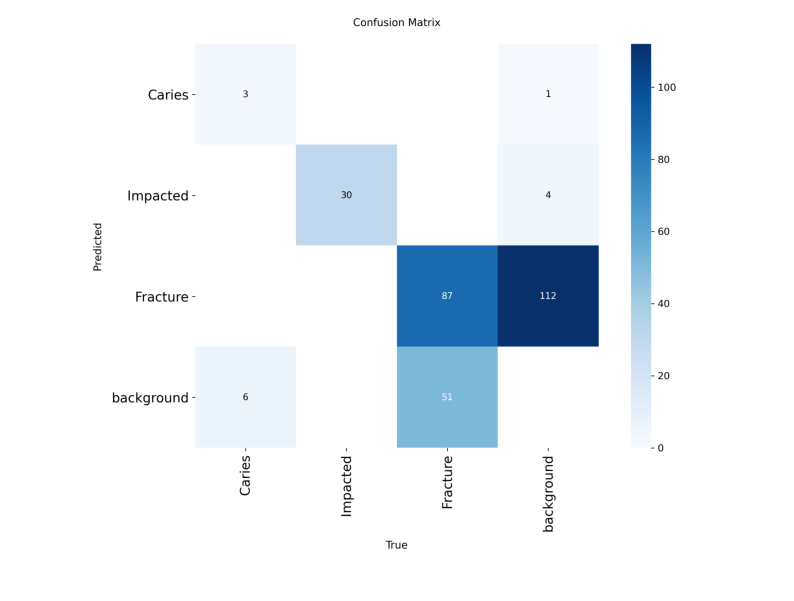

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Визначення шляху до моделі
model_path = '/content/dental_yolo_project/run_v1/weights/best.pt'

# Перевірка наявності файлу
if not os.path.exists(model_path):
    # Перевірка альтернативного шляху (якщо YOLO зберегло в стандартну папку)
    model_path_alt = '/content/runs/detect/run_v1/weights/best.pt'
    if os.path.exists(model_path_alt):
        model_path = model_path_alt
    else:
        raise FileNotFoundError(f"Файл моделі не знайдено за шляхом: {model_path}")

print(f"Завантаження моделі: {model_path}")
model = YOLO(model_path)

# 2. Запуск валідації
yaml_path = '/content/dental_yolo_dataset/dataset.yaml'
metrics = model.val(data=yaml_path, split='val', verbose=False)

# 3. Вивід результатів
print("\n" + "="*50)
print("Результати тестування (Validation Set)")
print("="*50)
print(f"mAP@50-95: {metrics.box.map:.4f}")
print(f"mAP@50:    {metrics.box.map50:.4f}")
print(f"mAP@75:    {metrics.box.map75:.4f}")

print("-" * 50)
print("Деталізація по класах (mAP@50-95):")

names = metrics.names
for i, ap in enumerate(metrics.box.maps):
    cls_name = names[i]
    print(f"  {cls_name:<15}: {ap:.4f}")

print("="*50)

# 4. Відображення матриці плутанини
results_dir = os.path.dirname(os.path.dirname(model_path))
confusion_matrix_path = os.path.join(results_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print("\nМатриця плутанини:")
    img = cv2.imread(confusion_matrix_path)
    if img is not None:
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.show()

Детальна статистика (Таблиця) та Матриця плутанини


CLASS           | PRECISION  | RECALL     | F1-SCORE   | SUPPORT   
------------------------------------------------------------
Caries          | 0.7435     | 0.5556     | 0.6359     | 2         
Impacted        | 0.9677     | 0.9999     | 0.9836     | 30        
Fracture        | 0.4375     | 0.5507     | 0.4876     | 140       
------------------------------------------------------------
AVERAGE         | 0.5335     | 0.6291     | 0.5758     | 172



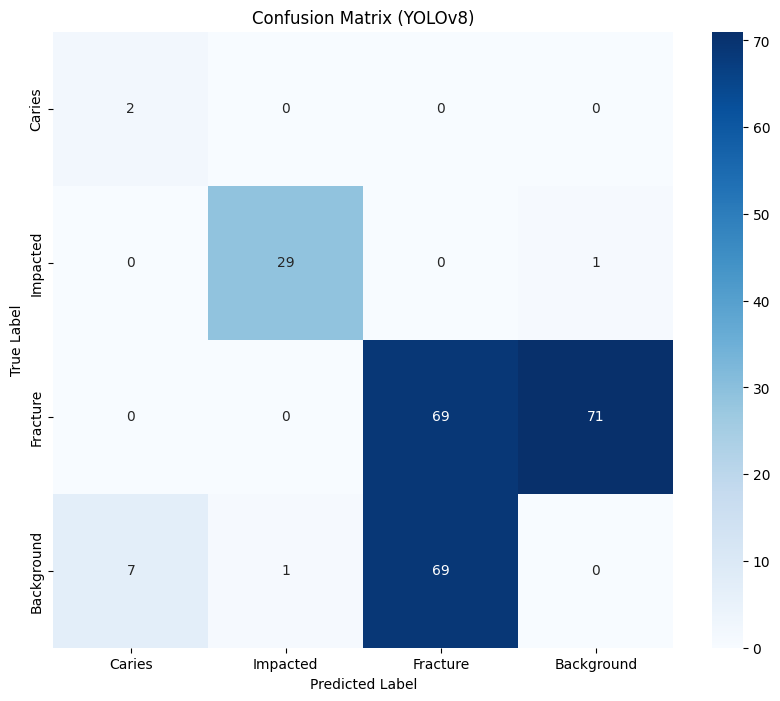

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


print("\n" + "="*60)
print(f"{'CLASS':<15} | {'PRECISION':<10} | {'RECALL':<10} | {'F1-SCORE':<10} | {'SUPPORT':<10}")
print("-" * 60)


p = metrics.box.p
r = metrics.box.r
f1 = metrics.box.f1


cm = metrics.confusion_matrix.matrix


names = metrics.names
avg_p, avg_r, avg_f1, total_support = 0, 0, 0, 0

for i, name in names.items():
    support = int(cm[i, :].sum())

    # Беремо значення метрики для класу (це значення при найкращому порозі)
    cls_p = p[i]
    cls_r = r[i]
    cls_f1 = f1[i]

    print(f"{name:<15} | {cls_p:.4f}     | {cls_r:.4f}     | {cls_f1:.4f}     | {support:<10}")

    avg_p += cls_p * support
    avg_r += cls_r * support
    avg_f1 += cls_f1 * support
    total_support += support

# Середньозважені значення
if total_support > 0:
    avg_p /= total_support
    avg_r /= total_support
    avg_f1 /= total_support

print("-" * 60)
print(f"{'AVERAGE':<15} | {avg_p:.4f}     | {avg_r:.4f}     | {avg_f1:.4f}     | {total_support}")
print("="*60 + "\n")


# 2. МАТРИЦЯ ПЛУТАНИНИ
plt.figure(figsize=(10, 8))


labels = list(names.values()) + ["Background"]

# Якщо розмір матриці відрізняється від розміру лейблів (іноді буває в старих версіях), обрізаємо лейбли
if cm.shape[0] == len(labels) - 1:
    labels = list(names.values())

sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (YOLOv8)')
plt.show()

Вигляд рамок

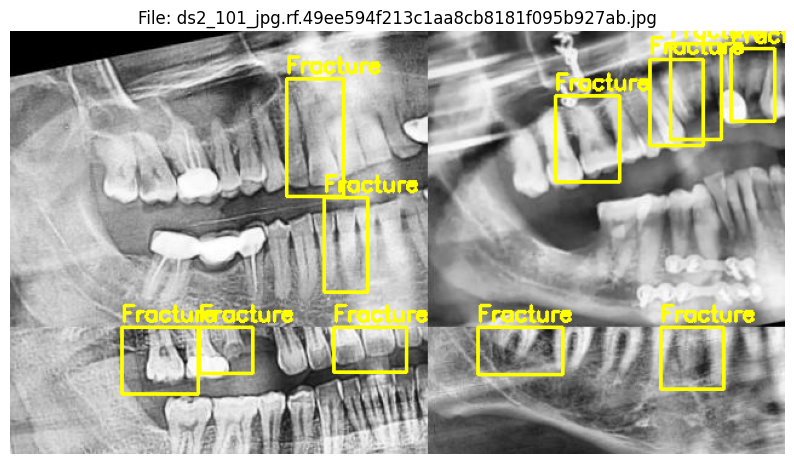

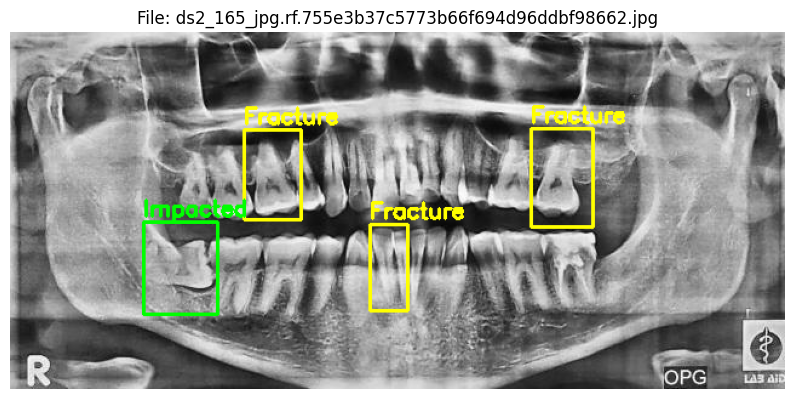

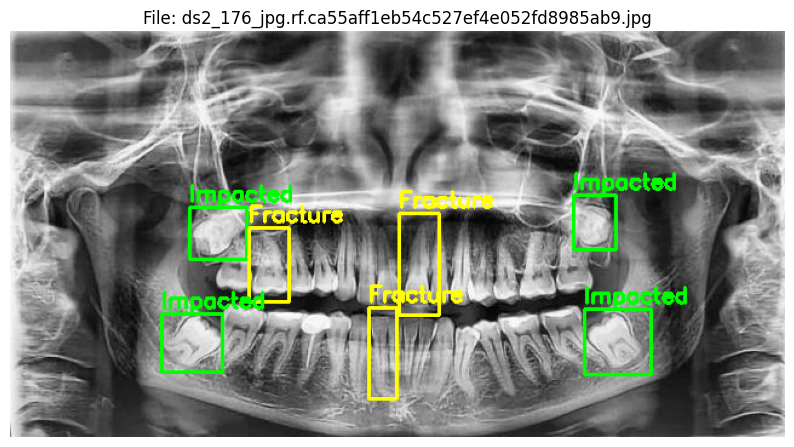

In [ ]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path


IMAGES_DIR = Path("/content/dental_yolo_dataset/train/images")
LABELS_DIR = Path("/content/dental_yolo_dataset/train/labels")

# Кольори класів
CLASS_COLORS = {
    0: (255, 0, 0),    # Caries (Червоний)
    1: (0, 255, 0),    # Impacted (Зелений)
    2: (255, 255, 0)   # Fracture (Жовтий)
}
CLASS_NAMES = {0: 'Caries', 1: 'Impacted', 2: 'Fracture'}

def visualize_yolo_ground_truth(num_samples=3):
    if not IMAGES_DIR.exists():
        print("Папка зображень не знайдена.")
        return

    all_images = list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.png"))

    if not all_images:
        print("Зображень не знайдено.")
        return

    selected_files = random.sample(all_images, min(num_samples, len(all_images)))

    for img_path in selected_files:

        img = cv2.imread(str(img_path))
        if img is None: continue
        h, w = img.shape[:2]
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


        label_path = LABELS_DIR / f"{img_path.stem}.txt"

        if label_path.exists():
            with open(label_path, 'r') as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                cls_id = int(parts[0])


                x_c, y_c, bw, bh = map(float, parts[1:])


                x1 = int((x_c - bw / 2) * w)
                y1 = int((y_c - bh / 2) * h)
                x2 = int((x_c + bw / 2) * w)
                y2 = int((y_c + bh / 2) * h)

                color = CLASS_COLORS.get(cls_id, (255, 255, 255))
                name = CLASS_NAMES.get(cls_id, str(cls_id))

                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, name, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"File: {img_path.name}")
        plt.show()

# Запуск
visualize_yolo_ground_truth(3)